In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
edades = pd.Series([22, 27, 31, 25, 29, 24, 26])

resumen = pd.Series({
    "media": edades.mean(),
    "mediana": edades.median(),
    "moda": edades.mode().iloc[0],
    "mínimo": edades.min(),
    "máximo": edades.max(),
    "rango": edades.max() - edades.min(),
    "varianza_muestral": edades.var(),
    "desviación_muestral": edades.std(),
    "Q1": edades.quantile(0.25),
    "Q3": edades.quantile(0.75),
    "IQR": edades.quantile(0.75) - edades.quantile(0.25),
})

print(resumen)

media                 26.29
mediana               26.00
moda                  22.00
mínimo                22.00
máximo                31.00
rango                  9.00
varianza_muestral      9.24
desviación_muestral    3.04
Q1                    24.50
Q3                    28.00
IQR                    3.50
dtype: float64


In [10]:
datos = pd.Series([10, 11, 11, 12, 12, 13, 14, 15])
datos_con_extremo = pd.concat([datos, pd.Series([60])], ignore_index=True)

comparacion = pd.DataFrame({
    "sin_extremo": [
        datos.mean(), datos.median(), datos.std(), datos.quantile(0.75) - datos.quantile(0.25)
    ],
    "con_extremo": [
        datos_con_extremo.mean(), datos_con_extremo.median(),
        datos_con_extremo.std(),
        datos_con_extremo.quantile(0.75) - datos_con_extremo.quantile(0.25)
    ],
}, index=["media", "mediana", "desviación estándar", "IQR"])

print(comparacion)

                     sin_extremo  con_extremo
media                      12.25        17.56
mediana                    12.00        12.00
desviación estándar         1.67        15.99
IQR                         2.25         3.00


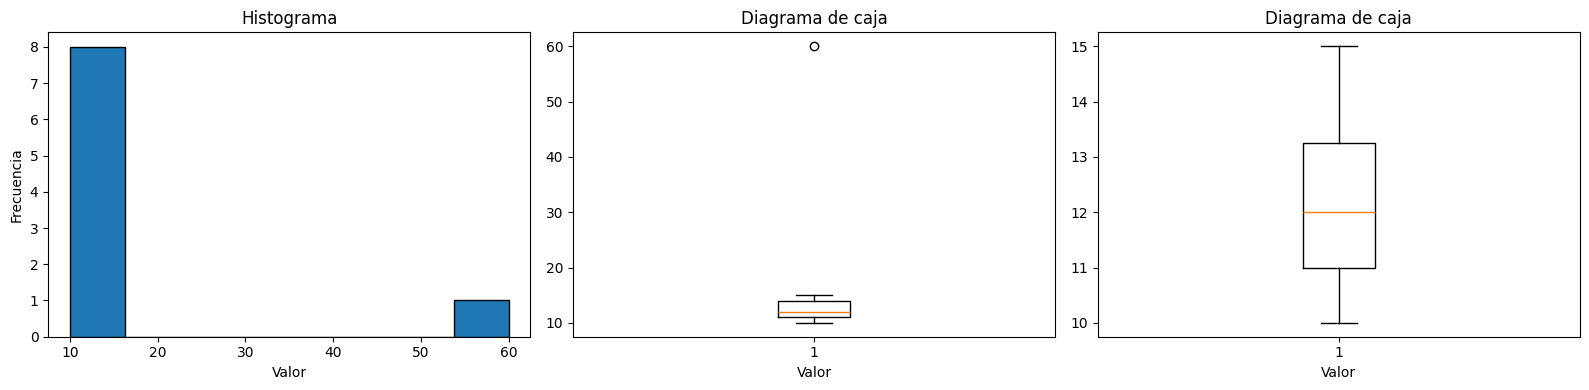

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(datos_con_extremo, bins=8, edgecolor="black")
axes[0].set_title("Histograma")
axes[0].set_xlabel("Valor")
axes[0].set_ylabel("Frecuencia")

axes[1].boxplot(datos_con_extremo)
axes[1].set_title("Datos con extremo")
axes[1].set_xlabel("Valor")

axes[2].boxplot(datos)
axes[2].set_title("Datos sin extremo")
axes[2].set_xlabel("Valor")

plt.tight_layout()
plt.show()

In [12]:
estudiantes = pd.DataFrame({
    "estudiante": ["Ana", "Luis", "María", "José", "Sofía", "Diego", "Elena", "Pablo"],
    "horas_estudio": [2, 4, 5, 3, 8, 6, 4, 10],
    "calificacion": [62, 70, 75, 68, 88, 80, 73, 91],
})

print(estudiantes)
print(estudiantes[["horas_estudio", "calificacion"]].describe())

  estudiante  horas_estudio  calificacion
0        Ana              2            62
1       Luis              4            70
2      María              5            75
3       José              3            68
4      Sofía              8            88
5      Diego              6            80
6      Elena              4            73
7      Pablo             10            91
       horas_estudio  calificacion
count           8.00          8.00
mean            5.25         75.88
std             2.66          9.93
min             2.00         62.00
25%             3.75         69.50
50%             4.50         74.00
75%             6.50         82.00
max            10.00         91.00


        horas_estudio  calificacion
mean             5.25         75.88
median           4.50         74.00
std              2.66          9.93
min              2.00         62.00
max             10.00         91.00
IQR              2.75         12.50


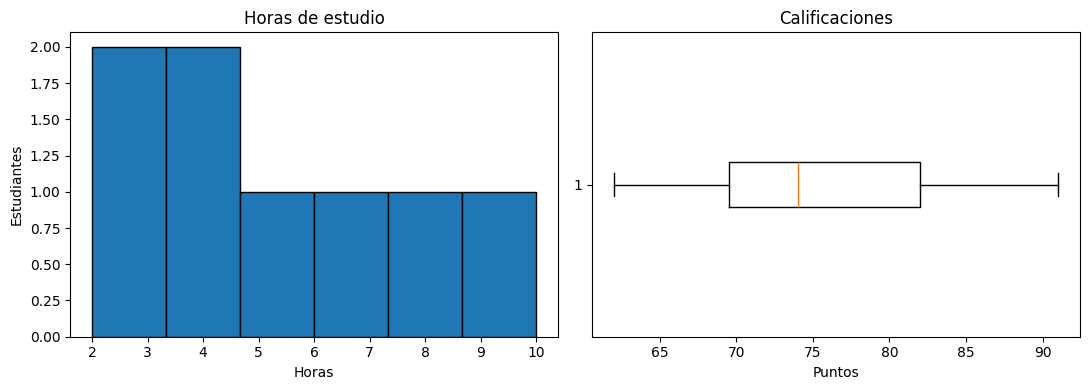

In [13]:
variables = ["horas_estudio", "calificacion"]

resumen = estudiantes[variables].agg(["mean", "median", "std", "min", "max"])
resumen.loc["IQR"] = (
    estudiantes[variables].quantile(0.75)
    - estudiantes[variables].quantile(0.25)
)
print(resumen)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(estudiantes["horas_estudio"], bins=6, edgecolor="black")
axes[0].set(title="Horas de estudio", xlabel="Horas", ylabel="Estudiantes")
axes[1].boxplot(estudiantes["calificacion"], vert=False)
axes[1].set(title="Calificaciones", xlabel="Puntos")
plt.tight_layout()
plt.show()


Correlación de Pearson: 0.986


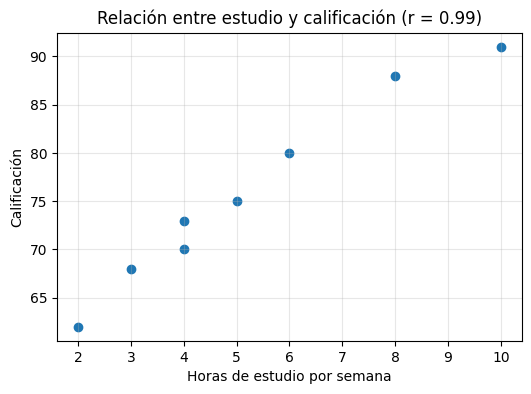

In [14]:
r = estudiantes["horas_estudio"].corr(estudiantes["calificacion"])
print(f"Correlación de Pearson: {r:.3f}")

plt.figure(figsize=(6, 4))
plt.scatter(estudiantes["horas_estudio"], estudiantes["calificacion"])
plt.xlabel("Horas de estudio por semana")
plt.ylabel("Calificación")
plt.title(f"Relación entre estudio y calificación (r = {r:.2f})")
plt.grid(alpha=0.3)
plt.show()

              temperatura  helados  insolaciones
temperatura          1.00     0.90          0.77
helados              0.90     1.00          0.69
insolaciones         0.77     0.69          1.00


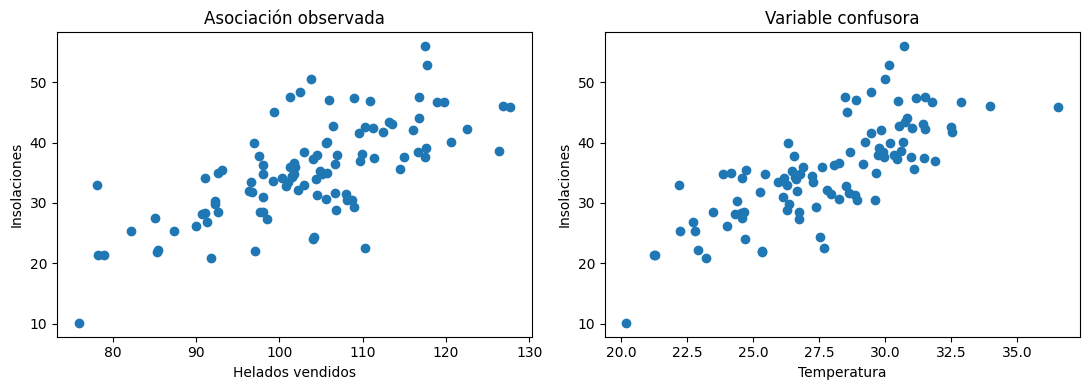

In [15]:
rng = np.random.default_rng(42)
n = 100
temperatura = rng.normal(28, 4, n)
helados = 20 + 3 * temperatura + rng.normal(0, 5, n)
insolaciones = -20 + 2 * temperatura + rng.normal(0, 5, n)

simulados = pd.DataFrame({
    "temperatura": temperatura,
    "helados": helados,
    "insolaciones": insolaciones,
})

print(simulados.corr(numeric_only=True).round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(simulados["helados"], simulados["insolaciones"])
axes[0].set(xlabel="Helados vendidos", ylabel="Insolaciones",
            title="Asociación observada")
axes[1].scatter(simulados["temperatura"], simulados["insolaciones"])
axes[1].set(xlabel="Temperatura", ylabel="Insolaciones",
            title="Variable confusora")
plt.tight_layout()
plt.show()